# Прогнозирование цен на недвижимость - разведочный анализ (EDA)

Датасет: **Ames Housing** (Kaggle, home-data-for-ml-course). Цель - изучить данные перед построением модели: посмотреть на целевую переменную `SalePrice`, пропуски, связи признаков с ценой.

**Задача - регрессия:** предсказать цену дома (число) по 79 признакам.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

# ищем папку с данными (работает и из notebooks/, и из корня проекта)
for d in ['../home-data-for-ml-course','home-data-for-ml-course','../data/raw','data/raw']:
    if (Path(d)/'train.csv').exists():
        DATA = Path(d); break
df = pd.read_csv(DATA/'train.csv')
print('Размер выборки:', df.shape)
df[['OverallQual','GrLivArea','GarageCars','YearBuilt','SalePrice']].head()

Размер выборки: (1460, 81)


,OverallQual,GrLivArea,GarageCars,YearBuilt,SalePrice
0,7,1710,2,2003,208500
1,6,1262,2,1976,181500
2,7,1786,2,2001,223500
3,7,1717,3,1915,140000
4,8,2198,3,2000,250000


## 1. Целевая переменная - цена продажи

Слева - цена в долларах (распределение скошено вправо, есть дорогие дома). Справа - логарифм цены: распределение становится близким к нормальному. Поэтому модель обучают на `log(цены)` - так ошибки на дорогих и дешёвых домах весят одинаково.

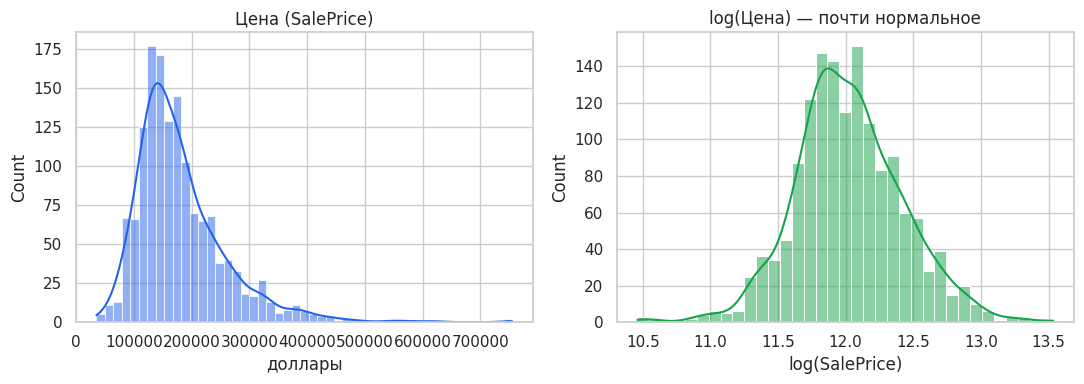

Цена: мин 34900, медиана 163000, макс 755000


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['SalePrice'], kde=True, ax=ax[0], color='#2563eb')
ax[0].set_title('Цена (SalePrice)'); ax[0].set_xlabel('доллары')
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=ax[1], color='#16a34a')
ax[1].set_title('log(Цена) - почти нормальное'); ax[1].set_xlabel('log(SalePrice)')
plt.tight_layout(); plt.show()
print('Цена: мин %d, медиана %d, макс %d' % (df.SalePrice.min(), df.SalePrice.median(), df.SalePrice.max()))

## 2. Пропуски в данных

В части колонок пропуск означает не «нет данных», а «нет такого элемента в доме» (нет бассейна `PoolQC`, нет переулка `Alley`). Это важно: их нельзя просто удалять - мы заменяем такие пропуски на «None» или 0.

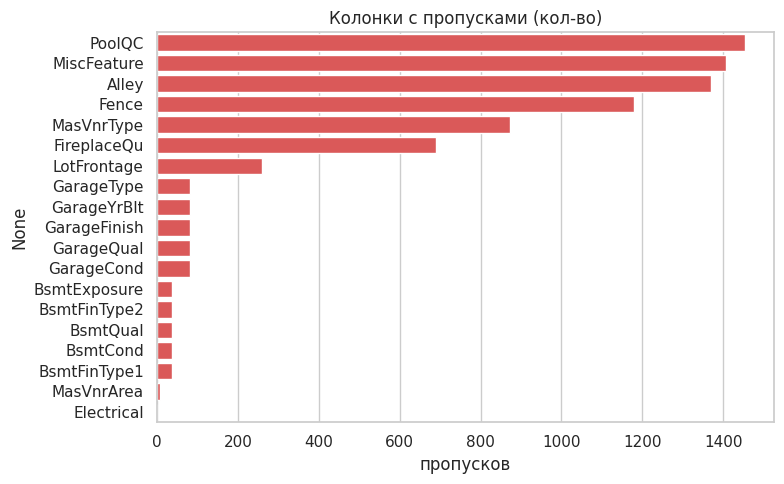

Всего колонок с пропусками: 19


In [3]:
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=na.values, y=na.index, color='#ef4444')
plt.title('Колонки с пропусками (кол-во)'); plt.xlabel('пропусков'); plt.tight_layout(); plt.show()
print('Всего колонок с пропусками:', len(na))

## 3. Какие признаки сильнее всего связаны с ценой

Корреляция показывает линейную связь признака с ценой (ближе к 1 - сильнее). Видно, что важнее всего общее качество дома `OverallQual` и жилая площадь `GrLivArea`.

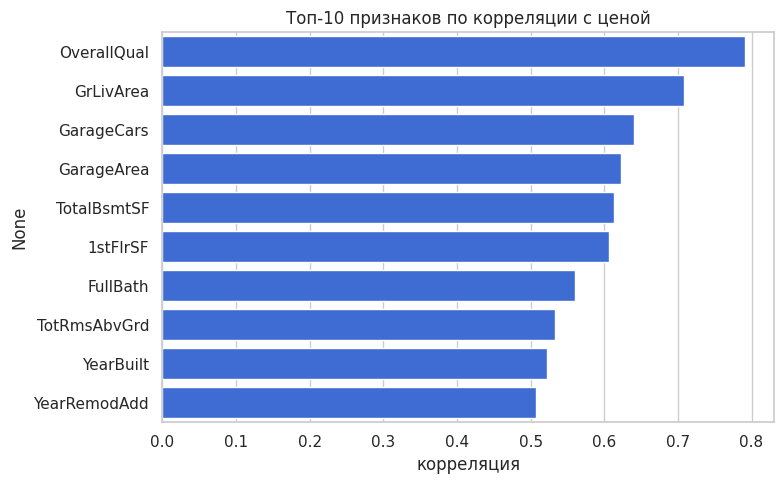

OverallQual     0.79
GrLivArea       0.71
GarageCars      0.64
GarageArea      0.62
TotalBsmtSF     0.61
1stFlrSF        0.61
FullBath        0.56
TotRmsAbvGrd    0.53
YearBuilt       0.52
YearRemodAdd    0.51
Name: SalePrice, dtype: float64

In [4]:
num = df.select_dtypes('number')
corr = num.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)
top = corr.head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=top.values, y=top.index, color='#2563eb')
plt.title('Топ-10 признаков по корреляции с ценой'); plt.xlabel('корреляция'); plt.tight_layout(); plt.show()
top.round(2)

## 4. Качество и площадь против цены

Два самых важных признака. Чем выше оценка качества и больше площадь - тем дороже дом.

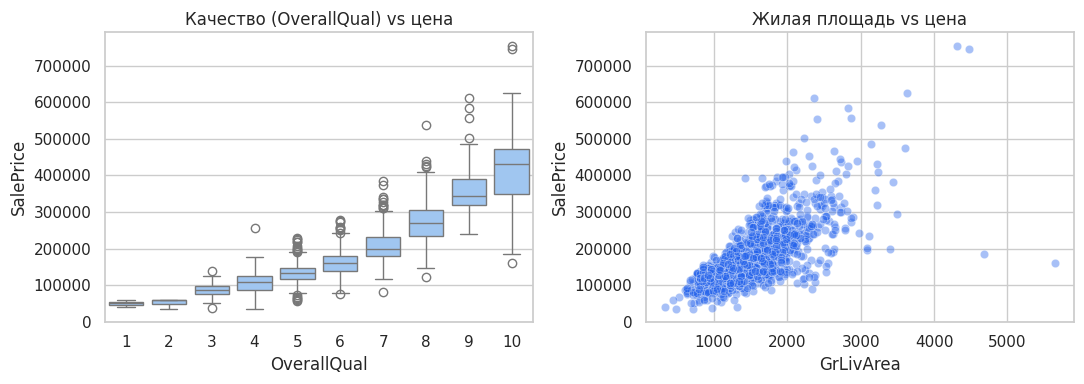

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=ax[0], color='#93c5fd')
ax[0].set_title('Качество (OverallQual) vs цена')
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df, ax=ax[1], alpha=0.4, color='#2563eb')
ax[1].set_title('Жилая площадь vs цена')
plt.tight_layout(); plt.show()

## 5. Район тоже влияет на цену

Медианная цена сильно зависит от района (`Neighborhood`) - поэтому категориальные признаки нужно кодировать и передавать модели.

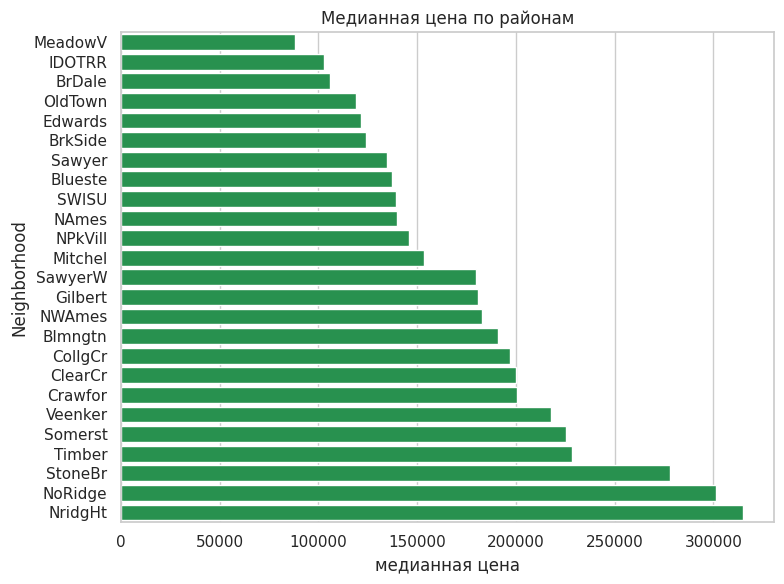

In [6]:
med = df.groupby('Neighborhood')['SalePrice'].median().sort_values()
plt.figure(figsize=(8, 6))
sns.barplot(x=med.values, y=med.index, color='#16a34a')
plt.title('Медианная цена по районам'); plt.xlabel('медианная цена'); plt.tight_layout(); plt.show()

## Выводы

- Цену лучше предсказывать в логарифме - распределение становится нормальным.
- Главные признаки: общее качество, жилая площадь, гараж, год постройки, район.
- Часть пропусков осмысленные (нет элемента) - заполняем «None»/0, а не удаляем.
- Дальше: кодируем категории, создаём новые признаки и обучаем модель (см. `src/`).